##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you will learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in the [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert them into NumPy arrays suitable for the model.

3. Resize the images before inference to match the model's expected input size (640x640) using `keras_cv.layers.Resizing`.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:
    - Which objects were detected correctly
    - The confidence scores of the detections
    - Any missed or incorrectly labeled objects


### Step 1: Install Required Libraries

In [1]:
!pip install --quiet keras-cv tensorflow keras
!pip install --quiet Pillow matplotlib


### Step 2: Import Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from urllib.request import Request, urlopen
from io import BytesIO

import tensorflow as tf
import keras_cv

print('TensorFlow version:', tf.__version__)
print('KerasCV version:', keras_cv.__version__)


/opt/anaconda3/envs/cv_lab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.20.0
KerasCV version: 0.9.0


### Step 3: Load the Pre-trained YOLOv8 Model

In [ ]:
model = keras_cv.models.YOLOV8Detector.from_preset(
    'yolo_v8_m_pascalvoc',
    bounding_box_format='xywh',
)

print('YOLOv8 model loaded successfully!')
model.summary()


100%|██████████| 2.27k/2.27k [00:00<00:00, 2.00MB/s]


100%|██████████| 99.5M/99.5M [00:16<00:00, 6.37MB/s]


YOLOv8 model loaded successfully!


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │ 11,872,464 │ input_layer_1[0]… │
│ (Functional)        │ None, 192),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 384),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 576)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 960)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │    368,640 │ concatenate_5[0]… │
│ (Conv2D)            │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │      1,536 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 192),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 192)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    331,776 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        768 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    331,776 │ pa_fpn_p4p5_pre_

 Total params: 25,901,004 (98.80 MB)

 Trainable params: 25,867,884 (98.68 MB)

 Non-trainable params: 33,120 (129.38 KB)

### Step 4: Prepare Images from Pascal VOC Classes

selected 5 images covering different Pascal VOC classes: `dog`, `cat`, `car`, `bicycle` and  `person`.


In [ ]:
# Load the images

image_paths = [
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/bicycle.jpg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/car.jpg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/cat.jpeg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/dog.jpeg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/person.jpg",
]

expected_classes = ['bicycle', 'car', 'cat', 'dog', 'person']


def load_image(path):
    """Load a local image file and return as a NumPy RGB array."""
    pil_image = Image.open(path).convert('RGB')
    return np.array(pil_image)



images = []
for i, path in enumerate(image_paths):
    print(f"Loading image {i+1}: {path.split('/')[-1]} | expected class = {expected_classes[i]}")
    img_array = load_image(path)
    images.append(img_array)
    print(f"  Shape: {img_array.shape}, dtype: {img_array.dtype}")

print('\nAll images loaded successfully!')



Loading image 1: bicycle.jpg | expected class = bicycle
  Shape: (663, 1000, 3), dtype: uint8
Loading image 2: car.jpg | expected class = car
  Shape: (500, 1000, 3), dtype: uint8
Loading image 3: cat.jpeg | expected class = cat
  Shape: (183, 275, 3), dtype: uint8
Loading image 4: dog.jpeg | expected class = dog
  Shape: (137, 367, 3), dtype: uint8
Loading image 5: person.jpg | expected class = person
  Shape: (360, 540, 3), dtype: uint8

All images loaded successfully!


### Step 5: Resize Images for Inference


In [ ]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format='xywh'
)

resized_images = []
for i, img in enumerate(images):
    img_tensor = tf.cast(img, tf.float32)
    img_resized = inference_resizing(img_tensor[tf.newaxis, ...])  # shape: (1, 640, 640, 3)
    resized_images.append(img_resized)
    print(f"Image {i+1} resized to: {img_resized.shape}")


Image 1 resized to: (1, 640, 640, 3)
Image 2 resized to: (1, 640, 640, 3)
Image 3 resized to: (1, 640, 640, 3)
Image 4 resized to: (1, 640, 640, 3)
Image 5 resized to: (1, 640, 640, 3)


### Step 6: Pascal VOC Class Labels

Define the 20 class names in order, used to map class indices from model predictions to human-readable labels.


In [28]:
# Pascal VOC 2012 class names (20 classes, 0-indexed)
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

print('Pascal VOC Classes:')
for i, name in enumerate(VOC_CLASSES):
    print(f'  {i:2d}: {name}')


Pascal VOC Classes:
   0: aeroplane
   1: bicycle
   2: bird
   3: boat
   4: bottle
   5: bus
   6: car
   7: cat
   8: chair
   9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor


### Step 7: Run Inference with YOLOv8



In [ ]:
CONFIDENCE_THRESHOLD = 0.5  

all_predictions = []

for i, img_tensor in enumerate(resized_images):
    expected = expected_classes[i]
    print(f'\n--- Image {i+1}: {image_paths[i].split("/")[-1]} | Expected: {expected} ---')

    # Run model inference
    predictions = model.predict(img_tensor)
    all_predictions.append(predictions)

    # Extract outputs
    boxes       = predictions['boxes'][0]             # (num_det, 4)
    classes     = predictions['classes'][0]           # (num_det,)
    confidences = predictions['confidence'][0]        # (num_det,)
    num_det     = int(predictions['num_detections'][0])

    print(f'Total detections (above threshold): {num_det}')
    for j in range(num_det):
        class_id   = int(classes[j])
        class_name = VOC_CLASSES[class_id] if class_id < len(VOC_CLASSES) else f'class_{class_id}'
        confidence = float(confidences[j])
        box = boxes[j]
        print(f'  Detection {j+1}: {class_name} | Confidence: {confidence:.2f} | Box (xywh): {np.round(box, 1)}')



--- Image 1: bicycle.jpg | Expected: bicycle ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
Total detections (above threshold): 1
  Detection 1: bicycle | Confidence: 0.97 | Box (xywh): [  2.9   0.7 589.5 405.2]

--- Image 2: car.jpg | Expected: car ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
Total detections (above threshold): 1
  Detection 1: car | Confidence: 0.98 | Box (xywh): [ 59.7  47.7 528.7 212.4]

--- Image 3: cat.jpeg | Expected: cat ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
Total detections (above threshold): 1
  Detection 1: cat | Confidence: 0.98 | Box (xywh): [175.1   8.6 315.2 415.6]

--- Image 4: dog.jpeg | Expected: dog ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
Total detections (above threshold): 1
  Detection 1: dog | Confidence: 0.95 | Box (xywh): [203.1  19.2 263.2 218.4]

--- Image 5: person.jpg | Expected: person ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
Total detections (above threshold): 1
  Detection 1: person | Confidence: 0.98 | Box (xywh): [185.7  26.1 272.8

### Step 8: Visualize Predictions


/var/folders/9n/shtk5mk52gv63qh2m6jx6jfc0000gn/T/ipykernel_61410/3288219521.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(VOC_CLASSES))


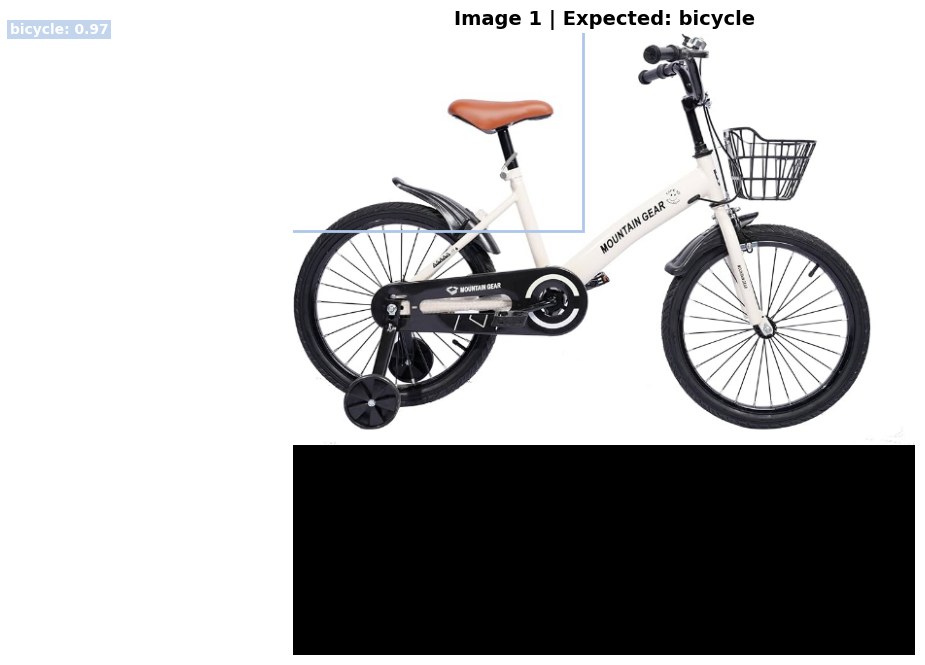

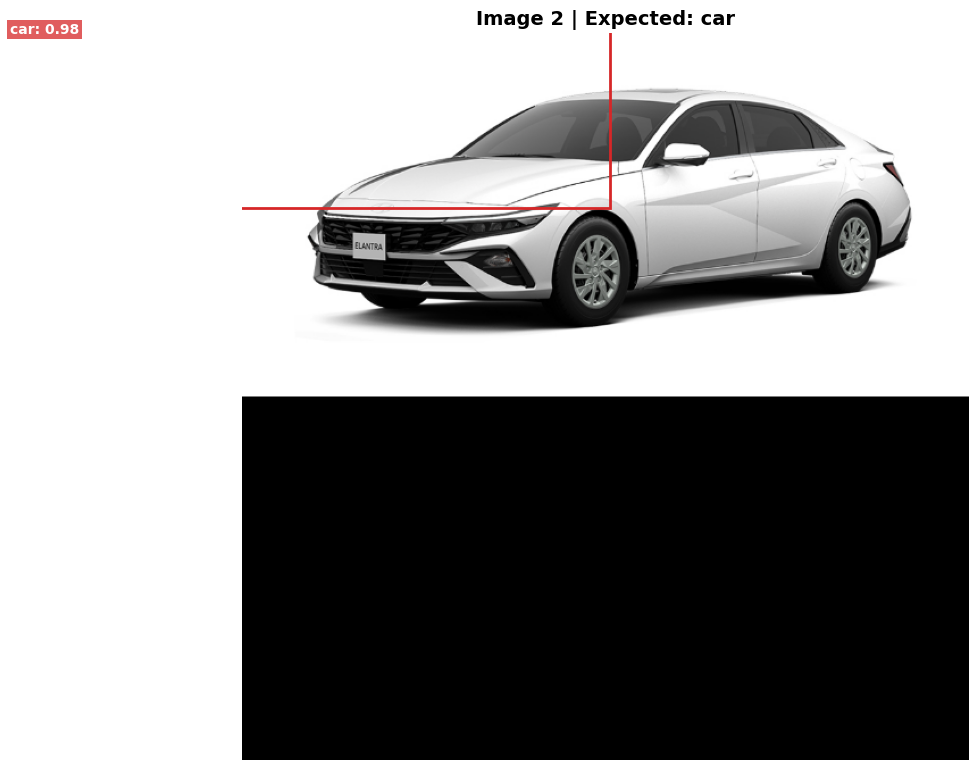

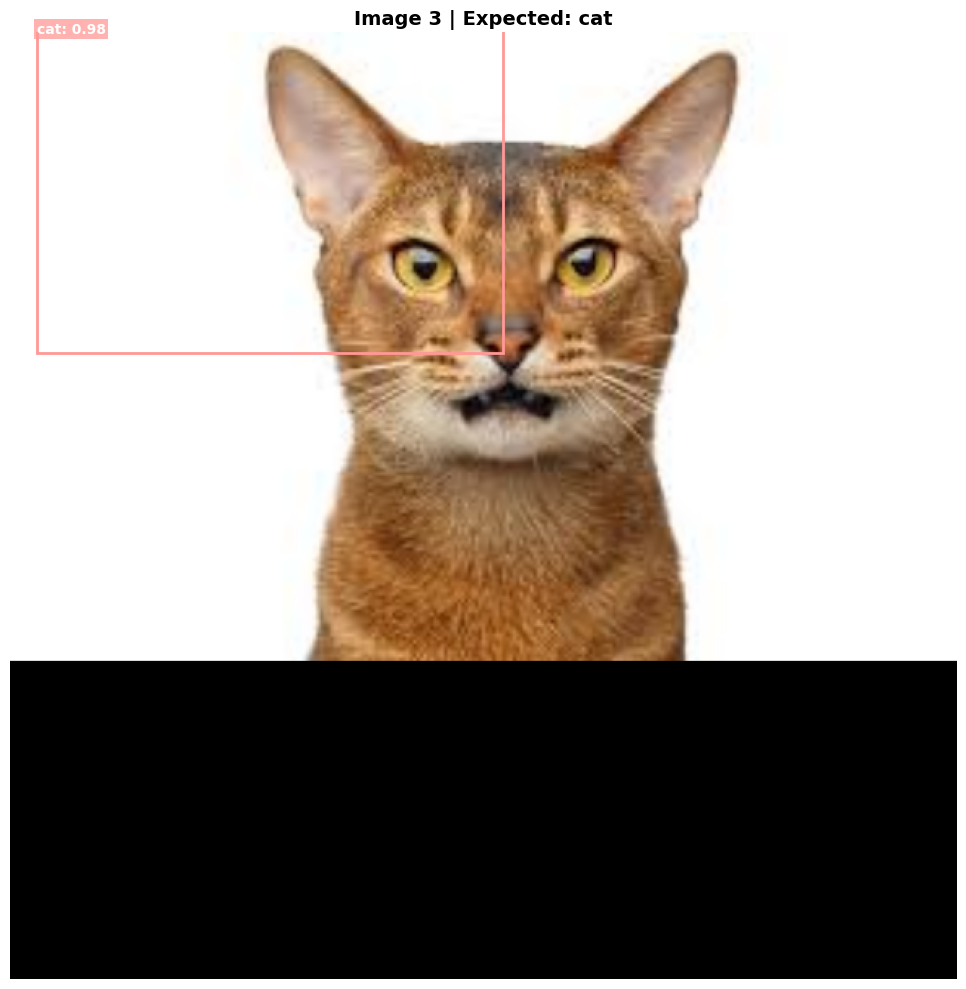

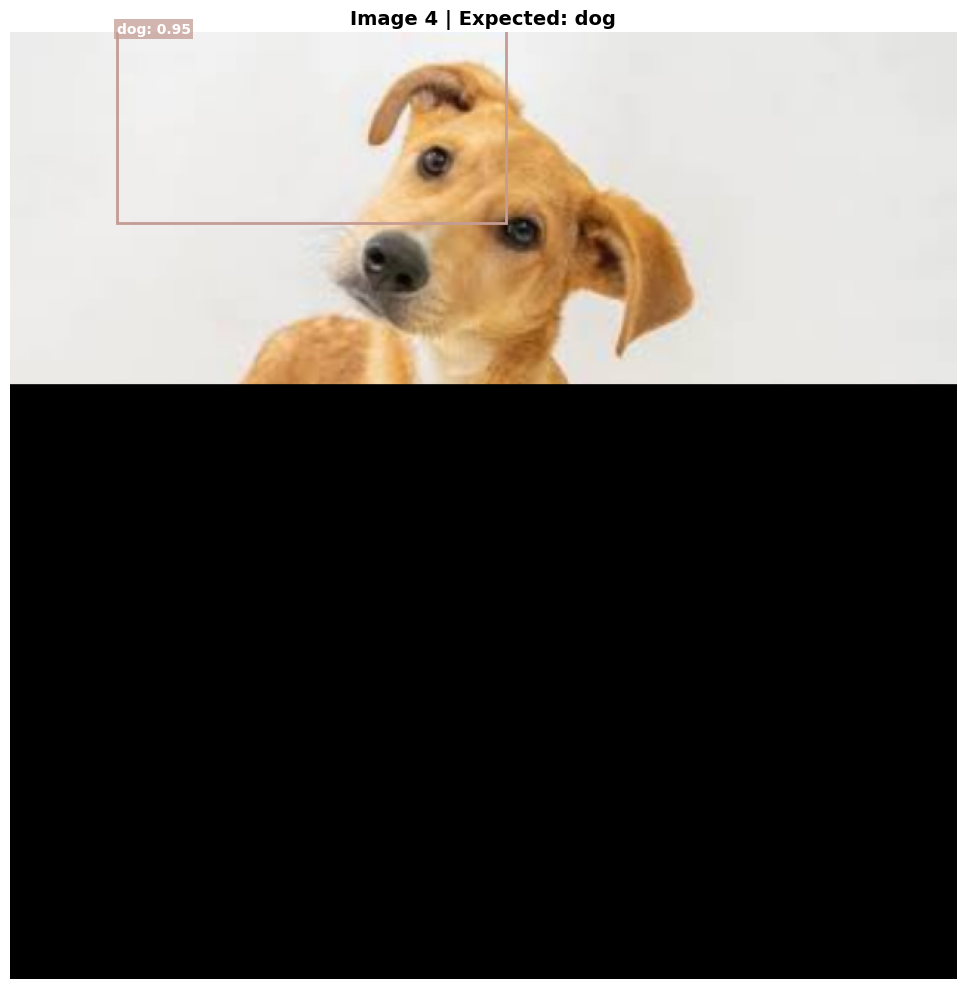

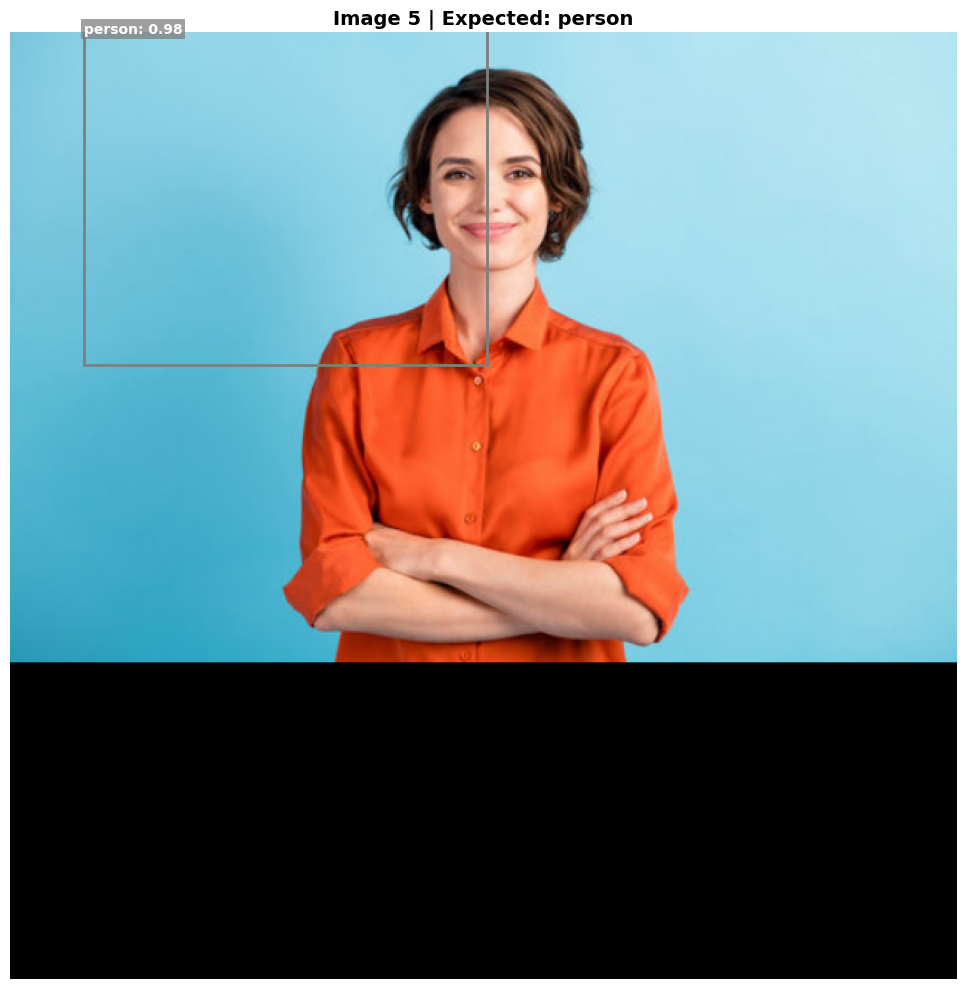

In [ ]:
def visualize_detections(image_np, predictions, title='', confidence_threshold=0.5):

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_np.astype(np.uint8))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    boxes       = predictions['boxes'][0]
    classes     = predictions['classes'][0]
    confidences = predictions['confidence'][0]
    num_det     = int(predictions['num_detections'][0])

    cmap = plt.cm.get_cmap('tab20', len(VOC_CLASSES))

    for j in range(num_det):
        confidence = float(confidences[j])
        if confidence < confidence_threshold:
            continue

        class_id   = int(classes[j])
        class_name = VOC_CLASSES[class_id] if class_id < len(VOC_CLASSES) else f'class_{class_id}'
        x_c, y_c, w, h = boxes[j]
        x_min = x_c - w / 2
        y_min = y_c - h / 2

        color = cmap(class_id)
        rect  = patches.Rectangle((x_min, y_min), w, h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        label = f'{class_name}: {confidence:.2f}'
        ax.text(x_min, max(y_min - 5, 0), label,
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.75, pad=2, edgecolor='none'))

    plt.tight_layout()
    plt.show()


# Visualize all 5 images
for i, (img_tensor, preds) in enumerate(zip(resized_images, all_predictions)):
    img_np   = img_tensor[0].numpy()
    expected = expected_classes[i]
    title    = f'Image {i+1} | Expected: {expected}'
    visualize_detections(img_np, preds, title=title, confidence_threshold=CONFIDENCE_THRESHOLD)


Image 1 — bicycle.jpg

Correctly detected: bicycle
Confidence: 0.97
No missed or incorrect detections


Image 2 — car.jpg

Correctly detected: car
Confidence: 0.98
No missed or incorrect detections


Image 3 — cat.jpeg

Correctly detected: cat
Confidence: 0.98
No missed detections, but the bounding box only covers the upper head/face area and misses the lower body


Image 4 — dog.jpeg

Correctly detected: dog
Confidence: 0.95
No missed detections, but the bounding box covers half of the head without the body


Image 5 — person.jpg


Correctly detected: person
Confidence: 0.98
No missed detections, but the bounding box only covers half of the face